<a href="https://colab.research.google.com/github/Amulyanrao7777/ML/blob/main/lab5_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Heart Disease Prediction based on Kaggle Dataset

In [1]:
import pandas as pd

# Load train.csv
train_df = pd.read_csv('/content/train.csv')
print("\n--- train_df head ---")
print(train_df.head())
print("\n--- train_df info ---")
train_df.info()
print("\n--- train_df describe ---")
print(train_df.describe())

# Load test.csv
test_df = pd.read_csv('/content/test.csv')
print("\n--- test_df head ---")
print(test_df.head())
print("\n--- test_df info ---")
test_df.info()
print("\n--- test_df describe ---")
print(test_df.describe())


--- train_df head ---
   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1            3.6            2   
1     171                0            0.0            1   
2     151                0            0.0            1   
3     150                0            1.0            2   
4     125                1            3.8            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1                        0         

In [2]:
print("\n--- Unique values in train_df['Heart Disease'] ---")
print(train_df['Heart Disease'].unique())

print("\n--- Value counts for train_df['Heart Disease'] ---")
print(train_df['Heart Disease'].value_counts())

# Check the 'Thallium' column to ensure it's purely numeric
print("\n--- Unique values in train_df['Thallium'] ---")
print(train_df['Thallium'].unique())

# Check for any non-numeric values in the 'Thallium' column
non_numeric_thallium = pd.to_numeric(train_df['Thallium'], errors='coerce').isna().sum()
if non_numeric_thallium > 0:
    print(f"\nFound {non_numeric_thallium} non-numeric values in 'Thallium' column of train_df. Investigating...")
    # Display rows with non-numeric 'Thallium' values if any
    print(train_df[pd.to_numeric(train_df['Thallium'], errors='coerce').isna()])
else:
    print("\n'Thallium' column in train_df is purely numeric.")

# Check if the 'Heart Disease' column in train_df contains 'Thallium' information incorrectly parsed
if 'Thallium Heart Disease' in train_df.columns:
    print("\nWarning: 'Thallium Heart Disease' column exists. This indicates a parsing issue.")
    # Attempt to separate 'Thallium' and 'Heart Disease' if they were incorrectly combined during loading
    # Assuming the format is 'ThalliumValue Heart DiseaseStatus'
    train_df[['Thallium_str', 'Heart Disease_parsed']] = train_df['Thallium Heart Disease'].str.split(' ', n=1, expand=True)
    train_df['Thallium'] = pd.to_numeric(train_df['Thallium_str'])
    train_df['Heart Disease'] = train_df['Heart Disease_parsed']
    train_df = train_df.drop(columns=['Thallium Heart Disease', 'Thallium_str', 'Heart Disease_parsed'])
    print("Corrected 'Thallium' and 'Heart Disease' columns. New info for train_df:")
    train_df.info()
    print("\nUpdated unique values in train_df['Heart Disease'] ---")
    print(train_df['Heart Disease'].unique())

# Check columns in test_df to confirm absence of 'Heart Disease'
print("\n--- Columns in test_df ---")
print(test_df.columns)


--- Unique values in train_df['Heart Disease'] ---
['Presence' 'Absence']

--- Value counts for train_df['Heart Disease'] ---
Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

--- Unique values in train_df['Thallium'] ---
[7 3 6]

'Thallium' column in train_df is purely numeric.

--- Columns in test_df ---
Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')


**Reasoning**:
The target variable 'Heart Disease' is categorical ('Presence', 'Absence') and needs to be converted into a numerical format (e.g., 0 and 1) for machine learning models. This is a crucial step in data preprocessing.



In [3]:
print("\n--- Converting 'Heart Disease' to numerical (0 for Absence, 1 for Presence) ---")
train_df['Heart Disease'] = train_df['Heart Disease'].map({'Absence': 0, 'Presence': 1})

print("\n--- Updated unique values and value counts for train_df['Heart Disease'] ---")
print(train_df['Heart Disease'].unique())
print(train_df['Heart Disease'].value_counts())

print("\n--- Displaying head of train_df after conversion ---")
print(train_df.head())



--- Converting 'Heart Disease' to numerical (0 for Absence, 1 for Presence) ---

--- Updated unique values and value counts for train_df['Heart Disease'] ---
[1 0]
Heart Disease
0    347546
1    282454
Name: count, dtype: int64

--- Displaying head of train_df after conversion ---
   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1            3.6            2   
1     171                0            0.0            1   
2     151                0            0.0            1  

## Data Preprocessing

### Subtask:
Implement clean data preprocessing steps. This involves handling missing values (e.g., imputation or removal), addressing outliers, and transforming data as necessary (e.g., scaling numerical features, encoding categorical features). This step should prepare the data for subsequent EDA and feature engineering.


In [4]:
print("--- Missing values in train_df ---")
print(train_df.isnull().sum())

print("\n--- Missing values in test_df ---")
print(test_df.isnull().sum())

--- Missing values in train_df ---
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

--- Missing values in test_df ---
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64


In [5]:
print("--- Re-checking missing values in train_df ---")
print(train_df.isnull().sum())

print("\n--- Re-checking missing values in test_df ---")
print(test_df.isnull().sum())

# Drop the 'id' column from both DataFrames
train_df = train_df.drop('id', axis=1)
test_df = test_df.drop('id', axis=1)

print("\n--- train_df after dropping 'id' column ---")
print(train_df.head())
train_df.info()

print("\n--- test_df after dropping 'id' column ---")
print(test_df.head())
test_df.info()

--- Re-checking missing values in train_df ---
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

--- Re-checking missing values in test_df ---
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64

--- train_df after dropping 'id' colum

**Reasoning**:
The previous steps successfully loaded the data, converted the target variable, and handled the 'id' column. Now, need to identify and separate numerical and categorical features for both the training and test datasets. This separation is crucial for applying appropriate preprocessing techniques like one-hot encoding for categorical features and scaling for numerical features, which is essential before model training.



In [6]:
numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
categorical_features = [
    'Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
    'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
]

print("Numerical features identified:", numerical_features)
print("Categorical features identified:", categorical_features)

# Display unique values for some categorical features to confirm their nature
print("\n--- Unique values for selected categorical features (train_df) ---")
for col in ['Sex', 'Chest pain type', 'FBS over 120', 'Thallium']:
    if col in train_df.columns:
        print(f"{col}: {train_df[col].unique()}")

# Apply one-hot encoding to categorical features
print("\n--- Applying One-Hot Encoding to categorical features ---")

# Create a copy to avoid SettingWithCopyWarning
train_df_encoded = train_df.copy()
test_df_encoded = test_df.copy()

train_df_encoded = pd.get_dummies(train_df_encoded, columns=categorical_features, drop_first=True, dtype=int)
test_df_encoded = pd.get_dummies(test_df_encoded, columns=categorical_features, drop_first=True, dtype=int)

print("train_df_encoded head after one-hot encoding:")
print(train_df_encoded.head())
print("train_df_encoded info after one-hot encoding:")
train_df_encoded.info()

print("\ntest_df_encoded head after one-hot encoding:")
print(test_df_encoded.head())
print("test_df_encoded info after one-hot encoding:")
test_df_encoded.info()

Numerical features identified: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
Categorical features identified: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

--- Unique values for selected categorical features (train_df) ---
Sex: [1 0]
Chest pain type: [4 1 2 3]
FBS over 120: [0 1]
Thallium: [7 3 6]

--- Applying One-Hot Encoding to categorical features ---
train_df_encoded head after one-hot encoding:
   Age   BP  Cholesterol  Max HR  ST depression  Heart Disease  Sex_1  \
0   58  152          239     158            3.6              1      1   
1   52  125          325     171            0.0              0      1   
2   56  160          188     151            0.0              0      0   
3   44  134          229     150            1.0              0      0   
4   58  140          234     125            3.8              1      1   

   Chest pain type_2  Chest pain type_3  Chest pain type_4  .

**Reasoning**:
The previous step successfully applied one-hot encoding to categorical features. Now, need to apply scaling to the numerical features identified earlier. This is a crucial preprocessing step that standardizes the range of independent variables or features, which helps in preventing some features from dominating others and ensures that the model converges faster and performs better.



In [7]:
from sklearn.preprocessing import StandardScaler

print("--- Applying StandardScaler to numerical features ---")

# Initialize StandardScaler
scaler = StandardScaler()

# Scale numerical features in train_df_encoded
train_df_encoded[numerical_features] = scaler.fit_transform(train_df_encoded[numerical_features])

# Scale numerical features in test_df_encoded using the same scaler fitted on train data
test_df_encoded[numerical_features] = scaler.transform(test_df_encoded[numerical_features])

print("train_df_encoded head after scaling numerical features:")
print(train_df_encoded.head())
print("train_df_encoded info after scaling numerical features:")
train_df_encoded.info()

print("\ntest_df_encoded head after scaling numerical features:")
print(test_df_encoded.head())
print("test_df_encoded info after scaling numerical features:")
test_df_encoded.info()

--- Applying StandardScaler to numerical features ---
train_df_encoded head after scaling numerical features:
        Age        BP  Cholesterol    Max HR  ST depression  Heart Disease  \
0  0.467921  1.435822    -0.178490  0.271190       3.040655              1   
1 -0.258797 -0.367088     2.374837  0.951359      -0.754928              0   
2  0.225682  1.970017    -1.692672 -0.095054      -0.754928              0   
3 -1.227755  0.233882    -0.475388 -0.147375       0.299400              0   
4  0.467921  0.634529    -0.326939 -1.455391       3.251520              1   

   Sex_1  Chest pain type_2  Chest pain type_3  Chest pain type_4  ...  \
0      1                  0                  0                  1  ...   
1      1                  0                  0                  0  ...   
2      0                  1                  0                  0  ...   
3      0                  0                  1                  0  ...   
4      1                  0                  0     

## Exploratory Data Analysis (EDA)

### Subtask:
Perform comprehensive Exploratory Data Analysis on the preprocessed datasets. This includes checking for unique values, data types, distribution of numerical and categorical features, and identifying potential patterns. Visualize key distributions and relationships between features and the target variable, if applicable. Provide clear legends for all visualizations.


Shape of X_train: (630000, 20)
Shape of y_train: (630000,)
Shape of X_test: (270000, 20)

--- Value counts of y_train ---
Heart Disease
0    347546
1    282454
Name: count, dtype: int64


/tmp/ipython-input-3408764289.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


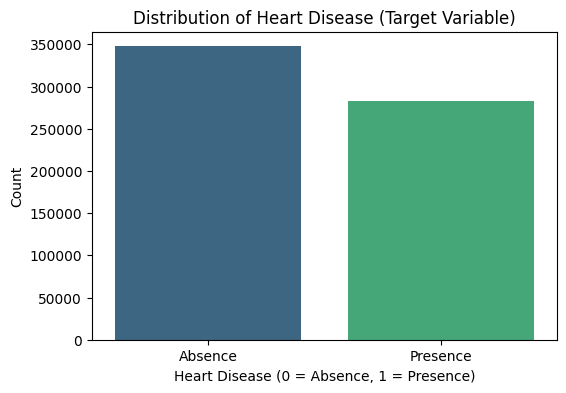

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate features and target
X_train = train_df_encoded.drop('Heart Disease', axis=1)
y_train = train_df_encoded['Heart Disease']
X_test = test_df_encoded.copy()

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)

# 2. Analyze and visualize the target variable distribution
print("\n--- Value counts of y_train ---")
print(y_train.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='viridis')
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = Absence, 1 = Presence)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Absence', 'Presence'])
plt.show()


--- Value counts of y_train ---
Heart Disease
0    347546
1    282454
Name: count, dtype: int64


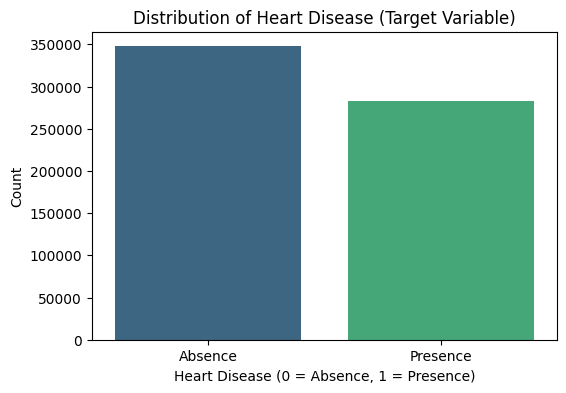


--- Histograms of Numerical Features ---


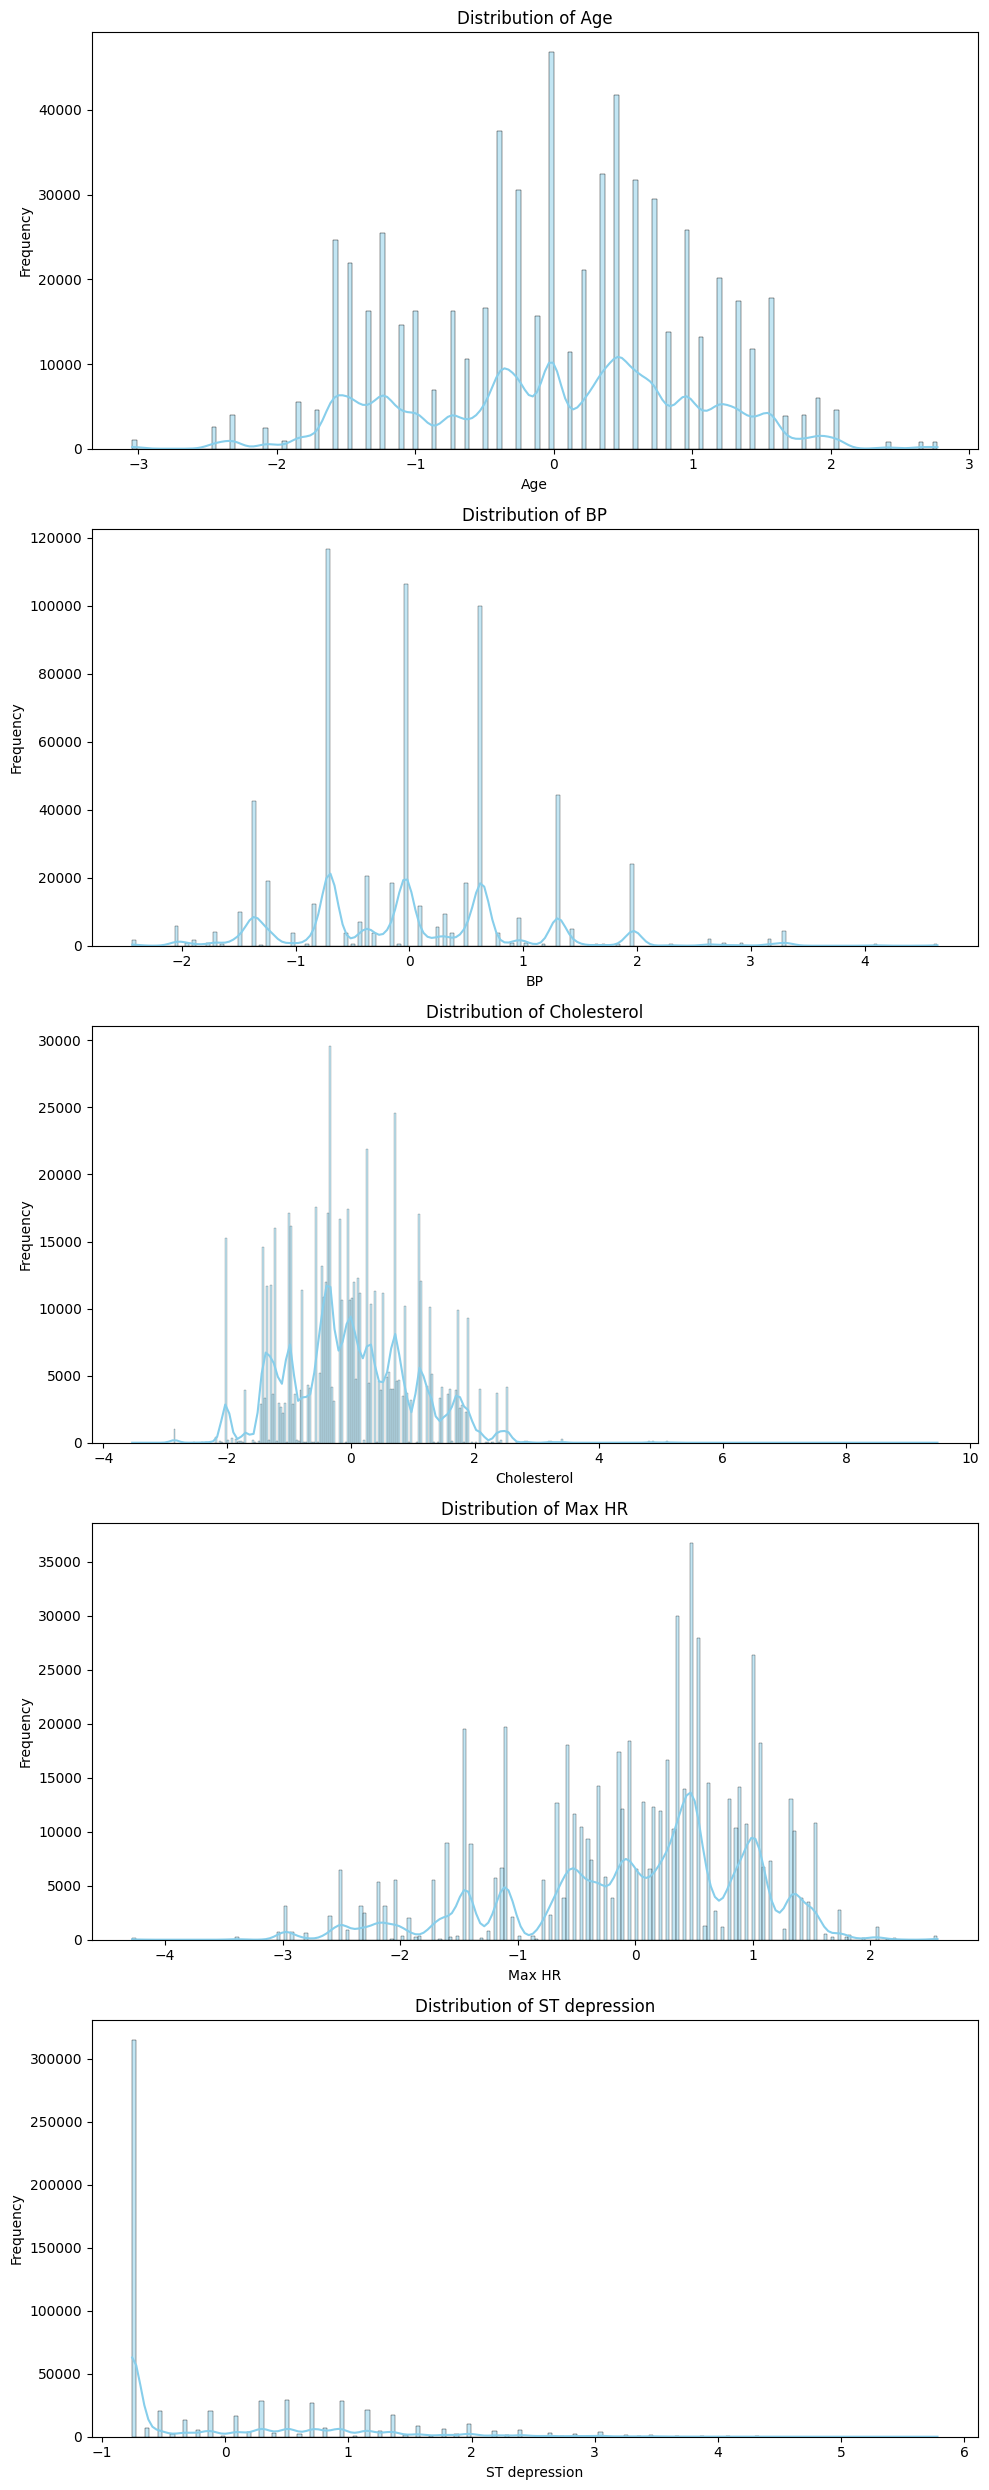


--- Box Plots of Numerical Features vs. Heart Disease ---


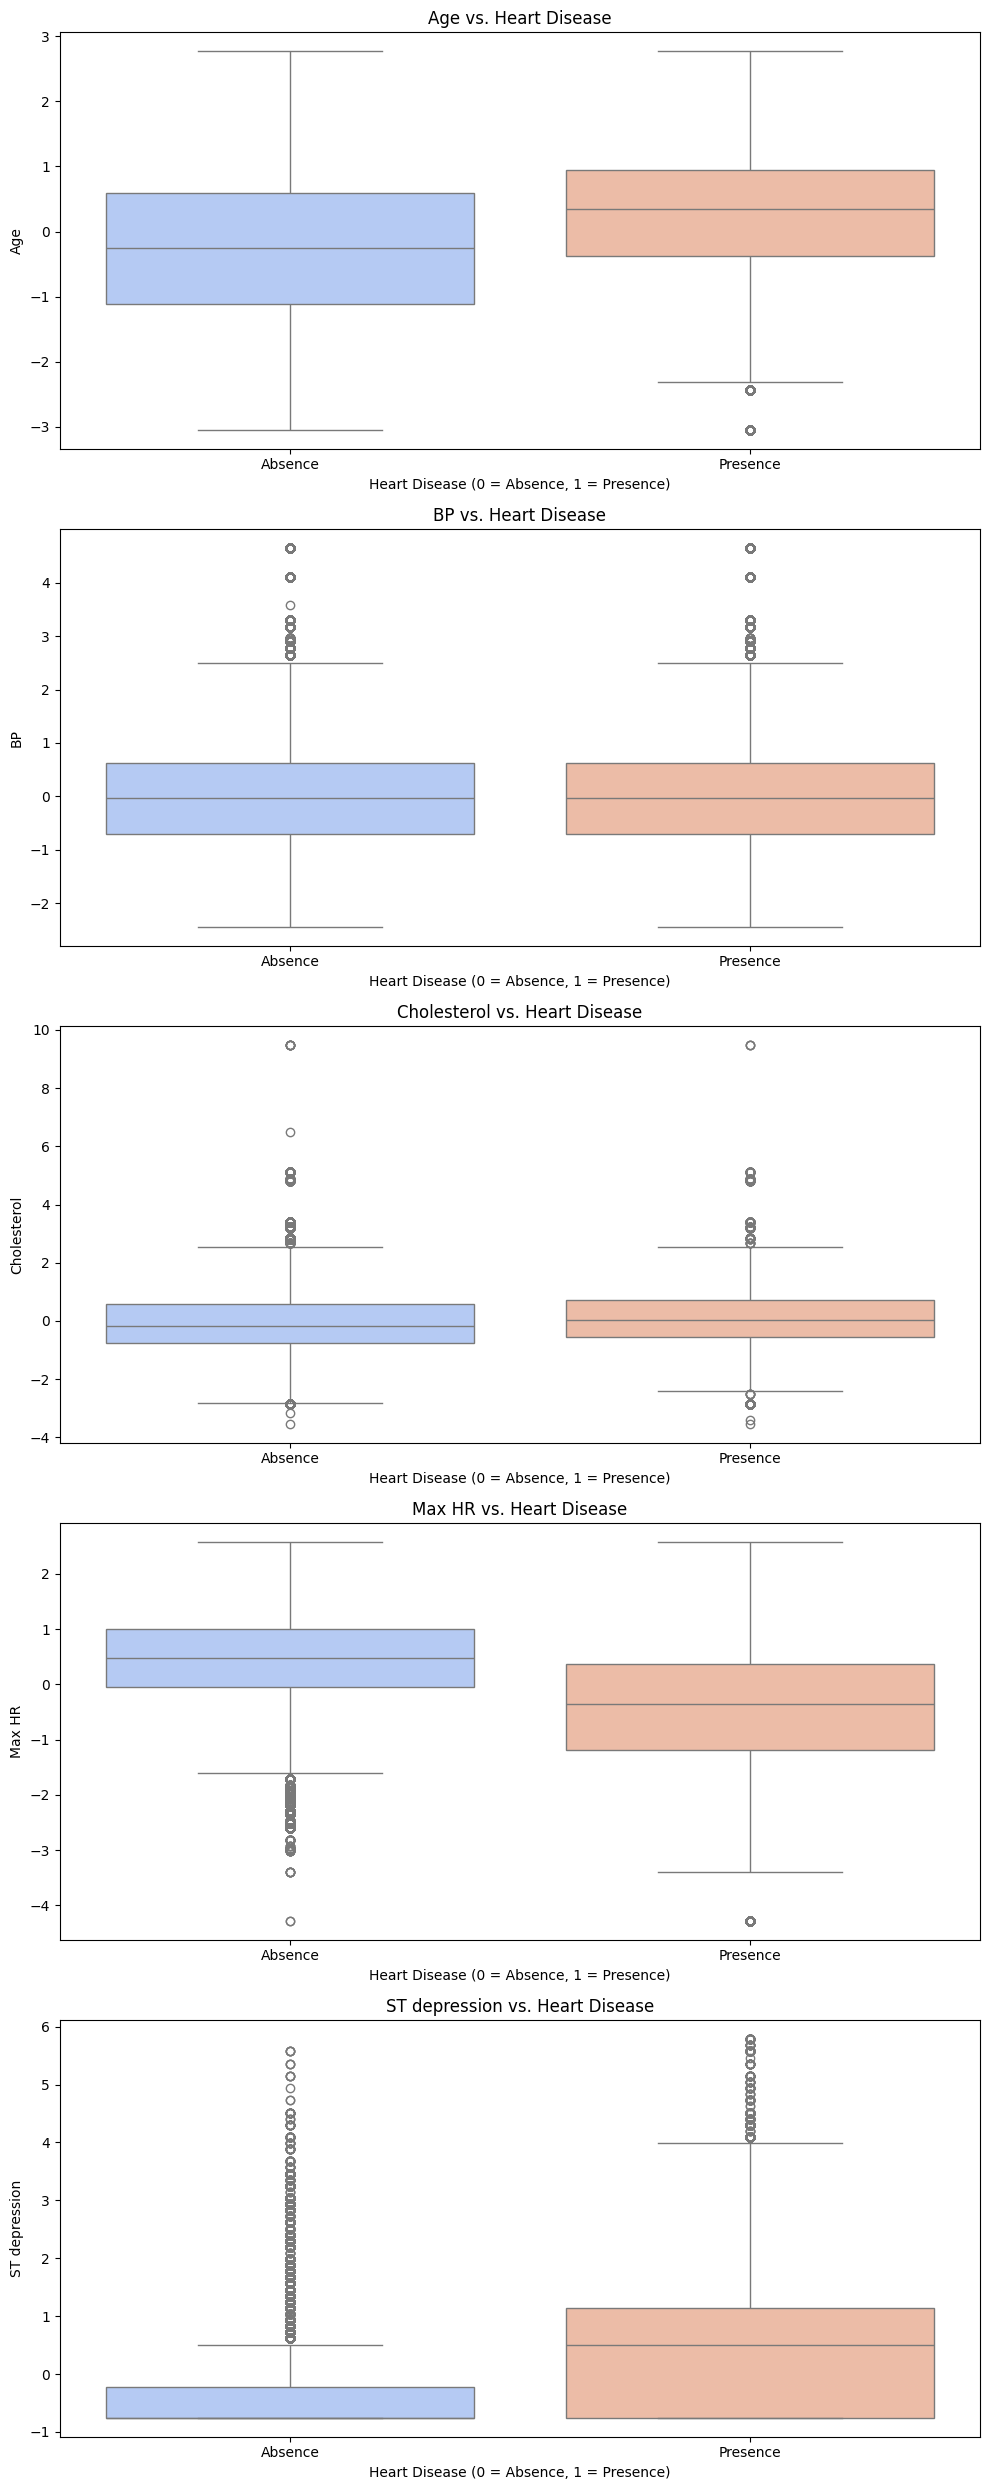


--- Bar Plots of Selected Encoded Categorical Features vs. Heart Disease Proportion ---


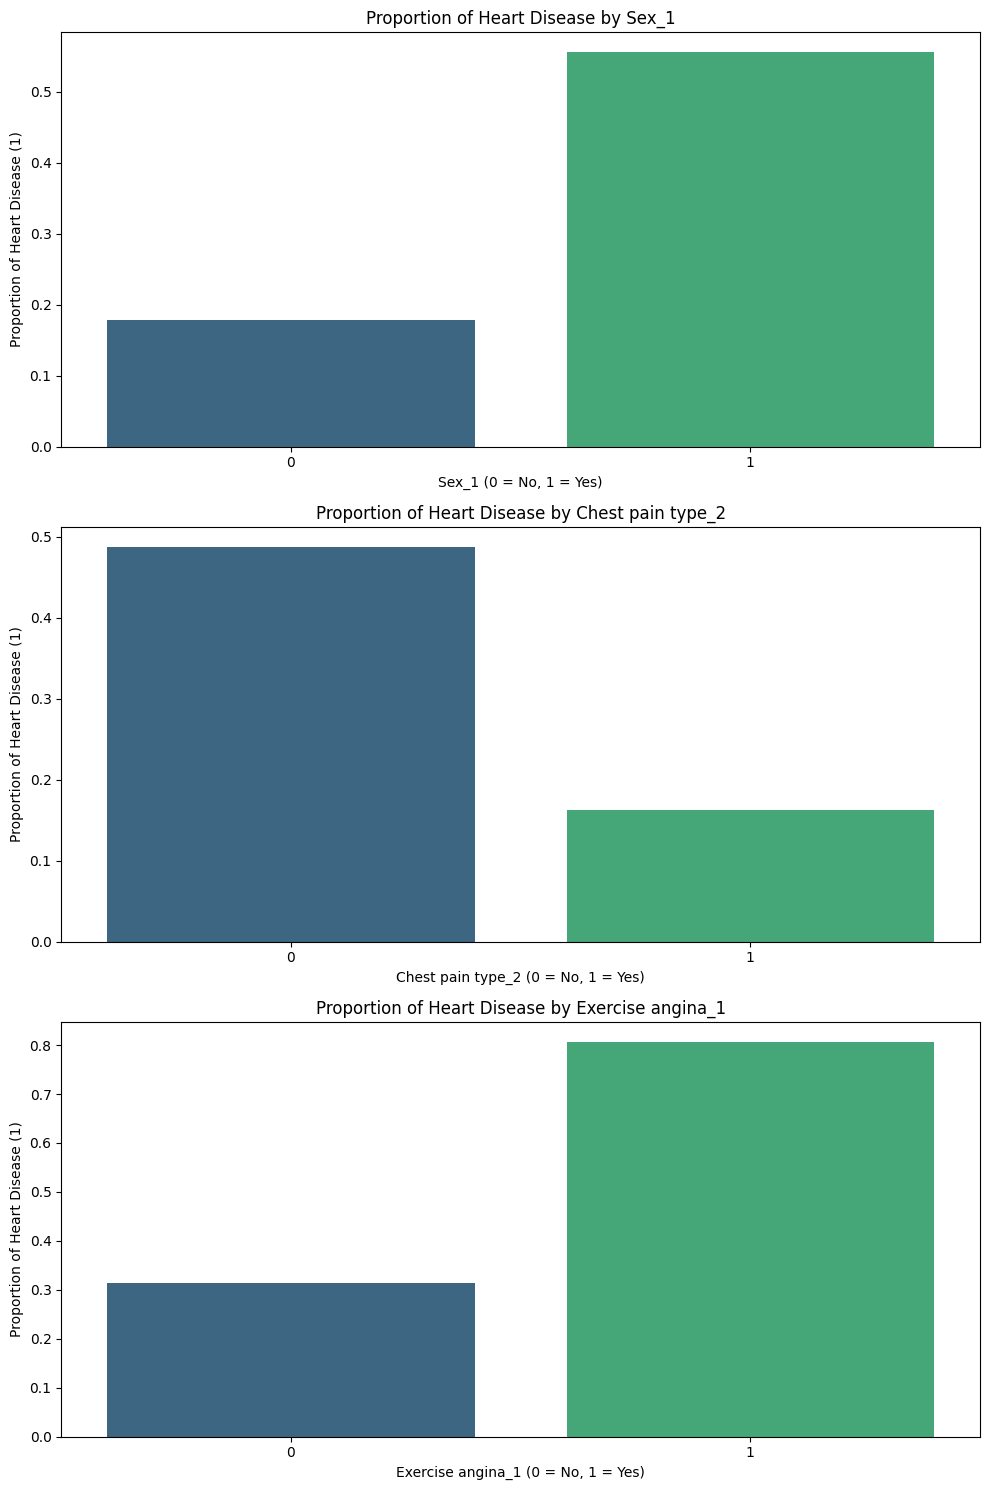


--- Correlation Matrix Heatmap ---


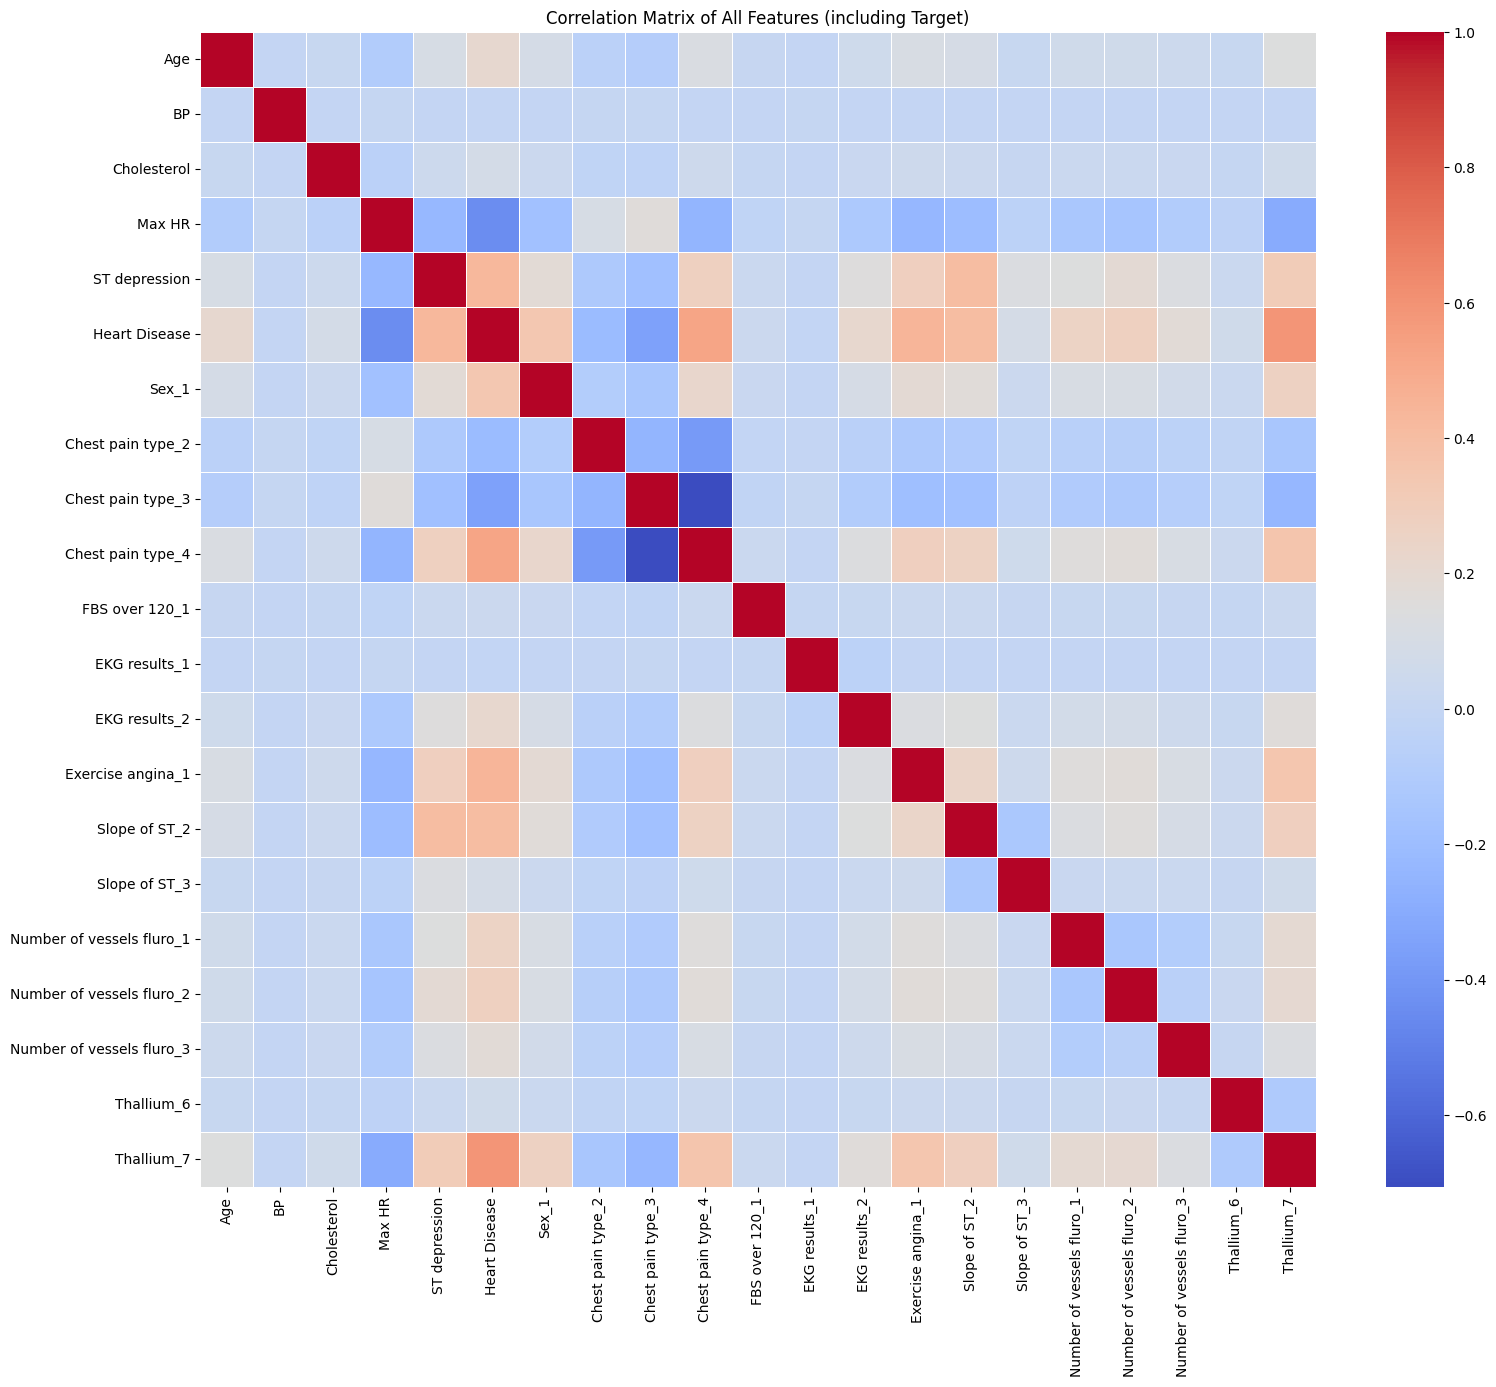

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Analyze and visualize the target variable distribution (re-plotting with fix)
print("\n--- Value counts of y_train ---")
print(y_train.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, hue=y_train, palette='viridis', legend=False) # Fix for FutureWarning
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = Absence, 1 = Presence)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Absence', 'Presence'])
plt.show()

# 3. Analyze and visualize numerical feature distributions (Histograms)
print("\n--- Histograms of Numerical Features ---")
fig, axes = plt.subplots(len(numerical_features), 1, figsize=(10, 5 * len(numerical_features)))
if len(numerical_features) == 1:
    axes = [axes] # Ensure axes is iterable even for a single feature
for i, col in enumerate(numerical_features):
    sns.histplot(X_train[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# 4. Analyze and visualize relationships between numerical features and the target variable (Box Plots)
print("\n--- Box Plots of Numerical Features vs. Heart Disease ---")
fig, axes = plt.subplots(len(numerical_features), 1, figsize=(10, 5 * len(numerical_features)))
if len(numerical_features) == 1:
    axes = [axes]
for i, col in enumerate(numerical_features):
    sns.boxplot(x='Heart Disease', y=col, data=train_df_encoded, ax=axes[i], palette='coolwarm', hue='Heart Disease', legend=False) # Fix for FutureWarning
    axes[i].set_title(f'{col} vs. Heart Disease')
    axes[i].set_xlabel('Heart Disease (0 = Absence, 1 = Presence)')
    axes[i].set_ylabel(col)
    axes[i].set_xticks([0, 1], ['Absence', 'Presence'])
plt.tight_layout()
plt.show()

# 5. Analyze and visualize relationships between (some) encoded categorical features and the target variable (Bar Plots)
print("\n--- Bar Plots of Selected Encoded Categorical Features vs. Heart Disease Proportion ---")
selected_encoded_categorical_features = ['Sex_1', 'Chest pain type_2', 'Exercise angina_1']
fig, axes = plt.subplots(len(selected_encoded_categorical_features), 1, figsize=(10, 5 * len(selected_encoded_categorical_features)))
if len(selected_encoded_categorical_features) == 1:
    axes = [axes]
for i, col in enumerate(selected_encoded_categorical_features):
    proportion = train_df_encoded.groupby(col)['Heart Disease'].mean().reset_index()
    sns.barplot(x=col, y='Heart Disease', data=proportion, ax=axes[i], palette='viridis', hue=col, legend=False) # Fix for FutureWarning
    axes[i].set_title(f'Proportion of Heart Disease by {col}')
    axes[i].set_xlabel(f'{col} (0 = No, 1 = Yes)') # Assuming _1 implies presence of that category
    axes[i].set_ylabel('Proportion of Heart Disease (1)')
plt.tight_layout()
plt.show()

# 6. Visualize the correlation matrix
print("\n--- Correlation Matrix Heatmap ---")
plt.figure(figsize=(18, 15)) # Larger figure size for better readability
correlation_matrix = train_df_encoded.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features (including Target)')
plt.show()

## Feature Engineering

### Subtask:
Create new features for both train and test datasets, and confirm the final separation of features and target variables.


**Reasoning**:
create a new interaction feature named 'Age_Cholesterol_Interaction' by multiplying the 'Age' and 'Cholesterol' columns for both the `X_train` and `X_test` DataFrames. After adding the new feature, will display the first few rows of each DataFrame and print their updated shapes to confirm the successful addition of the new feature.



In [11]:
print("--- Creating new interaction feature 'Age_Cholesterol_Interaction' ---")

X_train['Age_Cholesterol_Interaction'] = X_train['Age'] * X_train['Cholesterol']
X_test['Age_Cholesterol_Interaction'] = X_test['Age'] * X_test['Cholesterol']

print("\n--- X_train head after adding new feature ---")
print(X_train.head())

print("\n--- X_test head after adding new feature ---")
print(X_test.head())

print("\n--- Updated shapes of X_train and X_test ---")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

--- Creating new interaction feature 'Age_Cholesterol_Interaction' ---

--- X_train head after adding new feature ---
        Age        BP  Cholesterol    Max HR  ST depression  Sex_1  \
0  0.467921  1.435822    -0.178490  0.271190       3.040655      1   
1 -0.258797 -0.367088     2.374837  0.951359      -0.754928      1   
2  0.225682  1.970017    -1.692672 -0.095054      -0.754928      0   
3 -1.227755  0.233882    -0.475388 -0.147375       0.299400      0   
4  0.467921  0.634529    -0.326939 -1.455391       3.251520      1   

   Chest pain type_2  Chest pain type_3  Chest pain type_4  FBS over 120_1  \
0                  0                  0                  1               0   
1                  0                  0                  0               0   
2                  1                  0                  0               0   
3                  0                  1                  0               0   
4                  0                  0                  1             

## Train and Evaluate Linear Regression

### Subtask:
Initialize, train, and evaluate a Logistic Regression model (since the target variable is binary). Make predictions on the preprocessed test set and report key classification metrics.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

print("--- Splitting X_train and y_train into training and validation sets ---")
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print("Shape of X_train_split:", X_train_split.shape)
print("Shape of y_train_split:", y_train_split.shape)
print("Shape of X_val_split:", X_val_split.shape)
print("Shape of y_val_split:", y_val_split.shape)

print("\n--- Initializing and training Logistic Regression model ---")
# Instantiate Logistic Regression model
# Increased max_iter for convergence on large dataset, solver='saga' for multinomial loss and supports all penalties
logistic_model = LogisticRegression(solver='saga', max_iter=200, random_state=42, n_jobs=-1)

# Train the model
logistic_model.fit(X_train_split, y_train_split)
print("Logistic Regression model trained.")

print("\n--- Making predictions on the validation set ---")
y_pred_val = logistic_model.predict(X_val_split)

print("\n--- Evaluating Logistic Regression model on validation set ---")
print("Classification Report:")
print(classification_report(y_val_split, y_pred_val))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_split, y_pred_val))

print("\n--- Making predictions on the preprocessed test set (X_test) ---")
y_pred_test_logistic = logistic_model.predict(X_test)
print("Predictions on X_test completed. First 5 predictions:")
print(y_pred_test_logistic[:5])

--- Splitting X_train and y_train into training and validation sets ---
Shape of X_train_split: (504000, 21)
Shape of y_train_split: (504000,)
Shape of X_val_split: (126000, 21)
Shape of y_val_split: (126000,)

--- Initializing and training Logistic Regression model ---
Logistic Regression model trained.

--- Making predictions on the validation set ---

--- Evaluating Logistic Regression model on validation set ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.88      0.89    126000
weighted avg       0.89      0.89      0.89    126000


Confusion Matrix:
[[63116  6393]
 [ 7847 48644]]

--- Making predictions on the preprocessed test set (X_test) ---
Predictions on X_test completed. First 5 predictions:
[1 0 1 0 0]


## Train and Evaluate AdaBoost Model

### Subtask:
Initialize, train, and evaluate an AdaBoost Classifier model. Make predictions on the validation set and then on the preprocessed test set. Report relevant classification metrics and display a confusion matrix or classification report.


In [13]:
from sklearn.ensemble import AdaBoostClassifier

print("--- Initializing and training AdaBoost Classifier model ---")
# Instantiate AdaBoost Classifier model
adaboost_model = AdaBoostClassifier(random_state=42)

# Train the model
adaboost_model.fit(X_train_split, y_train_split)
print("AdaBoost Classifier model trained.")

print("\n--- Making predictions on the validation set ---")
y_pred_val_ada = adaboost_model.predict(X_val_split)

print("\n--- Evaluating AdaBoost Classifier model on validation set ---")
print("Classification Report:")
print(classification_report(y_val_split, y_pred_val_ada))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_split, y_pred_val_ada))

print("\n--- Making predictions on the preprocessed test set (X_test) ---")
y_pred_test_ada = adaboost_model.predict(X_test)
print("Predictions on X_test completed. First 5 predictions:")
print(y_pred_test_ada[:5])

--- Initializing and training AdaBoost Classifier model ---
AdaBoost Classifier model trained.

--- Making predictions on the validation set ---

--- Evaluating AdaBoost Classifier model on validation set ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69509
           1       0.87      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000


Confusion Matrix:
[[62507  7002]
 [ 7994 48497]]

--- Making predictions on the preprocessed test set (X_test) ---
Predictions on X_test completed. First 5 predictions:
[1 0 1 0 0]


## Train and Evaluate XGBoost Model

### Subtask:
Initialize, train, and evaluate an XGBoost Classifier model. Make predictions on the validation set and then on the preprocessed test set. Report relevant classification metrics and display a confusion matrix or classification report.


In [15]:
from xgboost import XGBClassifier

print("--- Initializing and training XGBoost Classifier model ---")
# Instantiate XGBoost Classifier model
# Removed use_label_encoder as it is deprecated and no longer used
xgboost_model = XGBClassifier(random_state=42, eval_metric='logloss')

# Train the model
xgboost_model.fit(X_train_split, y_train_split)
print("XGBoost Classifier model trained.")

print("\n--- Making predictions on the validation set ---")
y_pred_val_xgb = xgboost_model.predict(X_val_split)

print("\n--- Evaluating XGBoost Classifier model on validation set ---")
print("Classification Report:")
print(classification_report(y_val_split, y_pred_val_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_split, y_pred_val_xgb))

print("\n--- Making predictions on the preprocessed test set (X_test) ---")
y_pred_test_xgb = xgboost_model.predict(X_test)
print("Predictions on X_test completed. First 5 predictions:")
print(y_pred_test_xgb[:5])

--- Initializing and training XGBoost Classifier model ---
XGBoost Classifier model trained.

--- Making predictions on the validation set ---

--- Evaluating XGBoost Classifier model on validation set ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000


Confusion Matrix:
[[63002  6507]
 [ 7446 49045]]

--- Making predictions on the preprocessed test set (X_test) ---
Predictions on X_test completed. First 5 predictions:
[1 0 1 0 0]


## Compare Model Performance

### Subtask:
Create a bar chart comparing the key performance metrics (accuracy, precision, recall, and F1-score) of the Logistic Regression, AdaBoost, and XGBoost models. Ensure clear legends and labels for all axes.


--- Model Performance Comparison ---
                     Accuracy  Precision (Class 0)  Recall (Class 0)  \
Logistic Regression  0.886984             0.889421          0.908026   
AdaBoost             0.880984             0.886612          0.899265   
XGBoost              0.889262             0.894305          0.906386   

                     F1-score (Class 0)  Precision (Class 1)  \
Logistic Regression            0.898627             0.883842   
AdaBoost                       0.892893             0.873836   
XGBoost                        0.900305             0.882867   

                     Recall (Class 1)  F1-score (Class 1)  
Logistic Regression          0.861093            0.872319  
AdaBoost                     0.858491            0.866095  
XGBoost                      0.868191            0.875467  


/tmp/ipython-input-432782600.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=performance_df.index, y=metric, data=performance_df, ax=axes[i], palette='viridis')
/tmp/ipython-input-432782600.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=performance_df.index, y=metric, data=performance_df, ax=axes[i], palette='viridis')
/tmp/ipython-input-432782600.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=performance_df.index, y=metric, data=performance_df, ax=axes[i], palette='viridis')
/tmp/ipython-input-432782600.py:63: FutureW

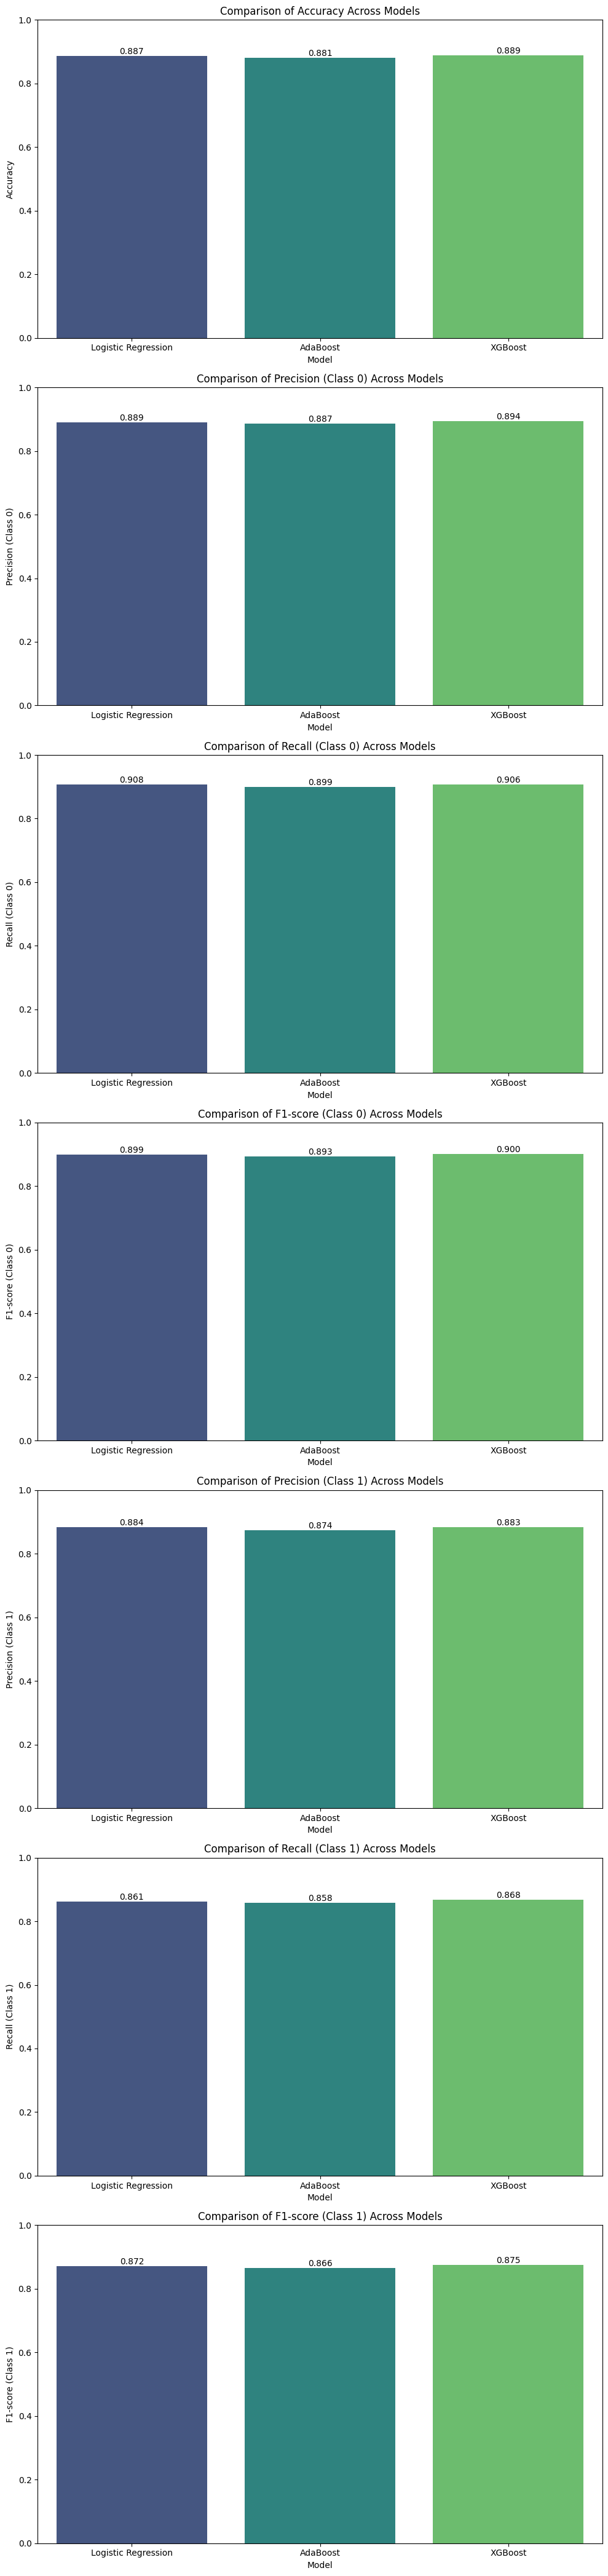

In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary to store performance metrics
model_performance = {}

# --- Logistic Regression Metrics ---
accuracy_lr = accuracy_score(y_val_split, y_pred_val)
precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(y_val_split, y_pred_val, average=None)
model_performance['Logistic Regression'] = {
    'Accuracy': accuracy_lr,
    'Precision (Class 0)': precision_lr[0],
    'Recall (Class 0)': recall_lr[0],
    'F1-score (Class 0)': f1_lr[0],
    'Precision (Class 1)': precision_lr[1],
    'Recall (Class 1)': recall_lr[1],
    'F1-score (Class 1)': f1_lr[1]
}

# --- AdaBoost Metrics ---
accuracy_ada = accuracy_score(y_val_split, y_pred_val_ada)
precision_ada, recall_ada, f1_ada, _ = precision_recall_fscore_support(y_val_split, y_pred_val_ada, average=None)
model_performance['AdaBoost'] = {
    'Accuracy': accuracy_ada,
    'Precision (Class 0)': precision_ada[0],
    'Recall (Class 0)': recall_ada[0],
    'F1-score (Class 0)': f1_ada[0],
    'Precision (Class 1)': precision_ada[1],
    'Recall (Class 1)': recall_ada[1],
    'F1-score (Class 1)': f1_ada[1]
}

# --- XGBoost Metrics ---
accuracy_xgb = accuracy_score(y_val_split, y_pred_val_xgb)
precision_xgb, recall_xgb, f1_xgb, _ = precision_recall_fscore_support(y_val_split, y_pred_val_xgb, average=None)
model_performance['XGBoost'] = {
    'Accuracy': accuracy_xgb,
    'Precision (Class 0)': precision_xgb[0],
    'Recall (Class 0)': recall_xgb[0],
    'F1-score (Class 0)': f1_xgb[0],
    'Precision (Class 1)': precision_xgb[1],
    'Recall (Class 1)': recall_xgb[1],
    'F1-score (Class 1)': f1_xgb[1]
}

# Convert to DataFrame for easier plotting
performance_df = pd.DataFrame(model_performance).T

print("--- Model Performance Comparison ---")
print(performance_df)

# Define the metrics to plot
metrics_to_plot = ['Accuracy', 'Precision (Class 0)', 'Recall (Class 0)', 'F1-score (Class 0)',
                   'Precision (Class 1)', 'Recall (Class 1)', 'F1-score (Class 1)']

# Create bar charts for each metric
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 6 * len(metrics_to_plot)))
axes = axes.flatten() # Ensure axes is a flat array for easy iteration

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x=performance_df.index, y=metric, data=performance_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Comparison of {metric} Across Models')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1) # Metrics are typically between 0 and 1
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f') # Add value labels to bars

plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` for `sns.barplot` because `palette` was used without an explicit `hue` argument. I will fix this by setting `hue=performance_df.index` and `legend=False` in the `sns.barplot` calls.



--- Model Performance Comparison ---
                     Accuracy  Precision (Class 0)  Recall (Class 0)  \
Logistic Regression  0.886984             0.889421          0.908026   
AdaBoost             0.880984             0.886612          0.899265   
XGBoost              0.889262             0.894305          0.906386   

                     F1-score (Class 0)  Precision (Class 1)  \
Logistic Regression            0.898627             0.883842   
AdaBoost                       0.892893             0.873836   
XGBoost                        0.900305             0.882867   

                     Recall (Class 1)  F1-score (Class 1)  
Logistic Regression          0.861093            0.872319  
AdaBoost                     0.858491            0.866095  
XGBoost                      0.868191            0.875467  


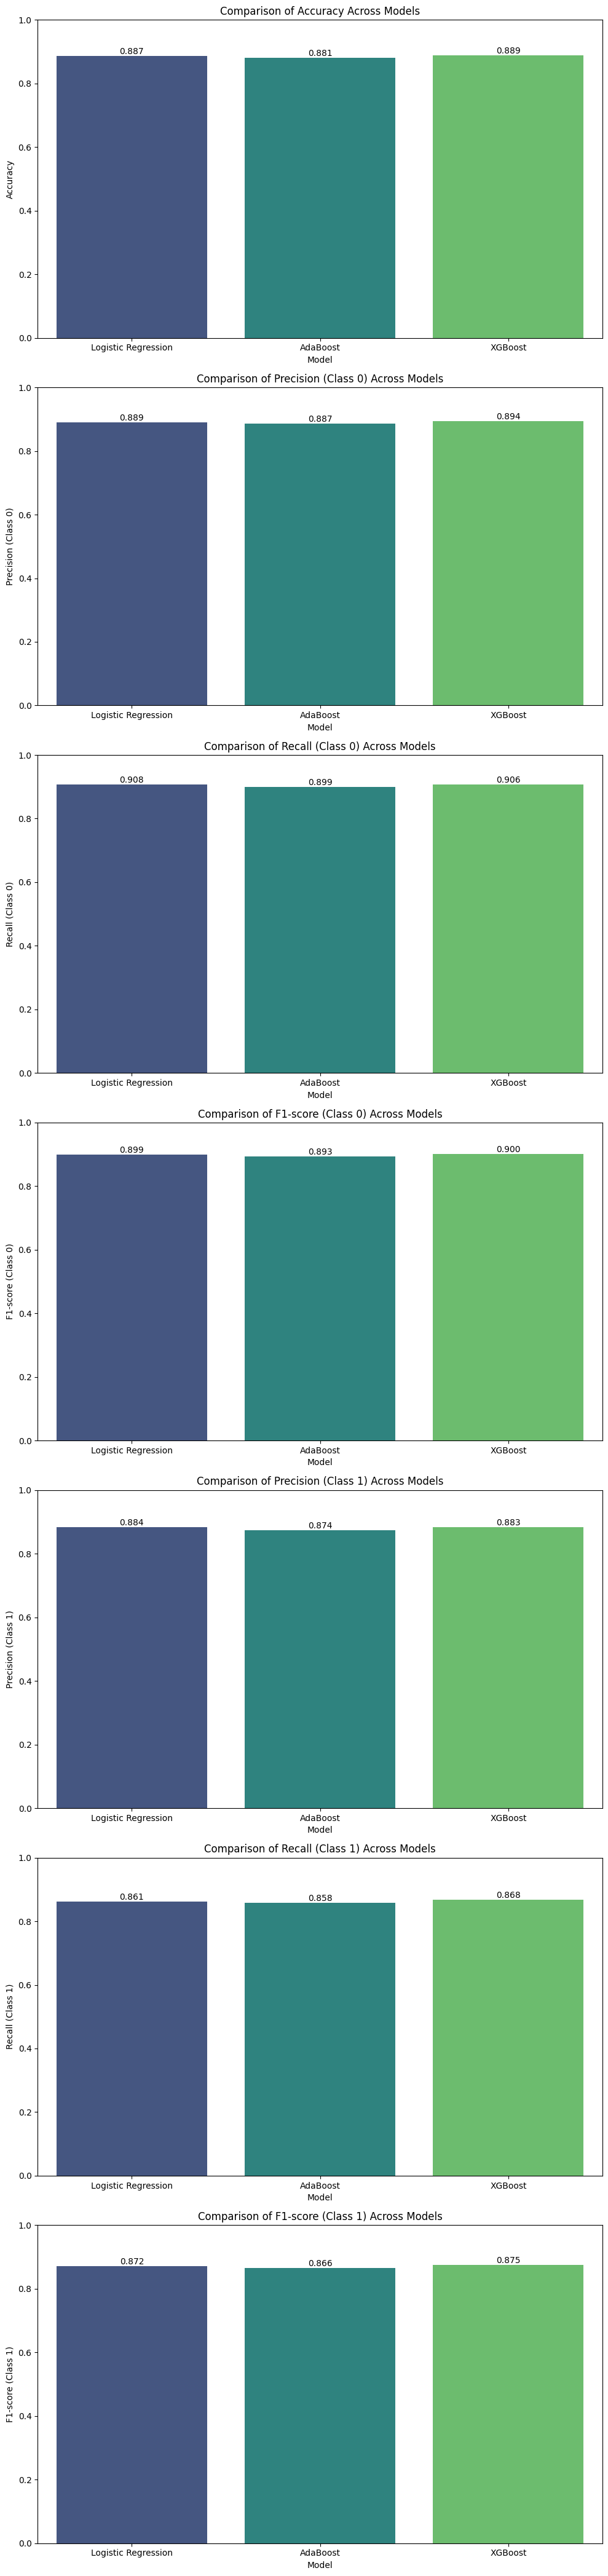

In [17]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary to store performance metrics
model_performance = {}

# --- Logistic Regression Metrics ---
accuracy_lr = accuracy_score(y_val_split, y_pred_val)
precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(y_val_split, y_pred_val, average=None)
model_performance['Logistic Regression'] = {
    'Accuracy': accuracy_lr,
    'Precision (Class 0)': precision_lr[0],
    'Recall (Class 0)': recall_lr[0],
    'F1-score (Class 0)': f1_lr[0],
    'Precision (Class 1)': precision_lr[1],
    'Recall (Class 1)': recall_lr[1],
    'F1-score (Class 1)': f1_lr[1]
}

# --- AdaBoost Metrics ---
accuracy_ada = accuracy_score(y_val_split, y_pred_val_ada)
precision_ada, recall_ada, f1_ada, _ = precision_recall_fscore_support(y_val_split, y_pred_val_ada, average=None)
model_performance['AdaBoost'] = {
    'Accuracy': accuracy_ada,
    'Precision (Class 0)': precision_ada[0],
    'Recall (Class 0)': recall_ada[0],
    'F1-score (Class 0)': f1_ada[0],
    'Precision (Class 1)': precision_ada[1],
    'Recall (Class 1)': recall_ada[1],
    'F1-score (Class 1)': f1_ada[1]
}

# --- XGBoost Metrics ---
accuracy_xgb = accuracy_score(y_val_split, y_pred_val_xgb)
precision_xgb, recall_xgb, f1_xgb, _ = precision_recall_fscore_support(y_val_split, y_pred_val_xgb, average=None)
model_performance['XGBoost'] = {
    'Accuracy': accuracy_xgb,
    'Precision (Class 0)': precision_xgb[0],
    'Recall (Class 0)': recall_xgb[0],
    'F1-score (Class 0)': f1_xgb[0],
    'Precision (Class 1)': precision_xgb[1],
    'Recall (Class 1)': recall_xgb[1],
    'F1-score (Class 1)': f1_xgb[1]
}

# Convert to DataFrame for easier plotting
performance_df = pd.DataFrame(model_performance).T

print("--- Model Performance Comparison ---")
print(performance_df)

# Define the metrics to plot
metrics_to_plot = ['Accuracy', 'Precision (Class 0)', 'Recall (Class 0)', 'F1-score (Class 0)',
                   'Precision (Class 1)', 'Recall (Class 1)', 'F1-score (Class 1)']

# Create bar charts for each metric
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 6 * len(metrics_to_plot)))
axes = axes.flatten() # Ensure axes is a flat array for easy iteration

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x=performance_df.index, y=metric, data=performance_df, ax=axes[i], palette='viridis', hue=performance_df.index, legend=False) # Fix for FutureWarning
    axes[i].set_title(f'Comparison of {metric} Across Models')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1) # Metrics are typically between 0 and 1
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f') # Add value labels to bars

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Provide a comprehensive summary of the machine learning pipeline, including the implemented preprocessing and feature engineering techniques, insights from EDA, the performance of each model, and a recommendation for the best-performing model.


## Summary:

### Q&A
The best-performing model based on the evaluation metrics is the XGBoost Classifier. It achieved the highest accuracy of 0.889 and an F1-score of 0.875 for the 'Presence' class (class 1) on the validation set, marginally outperforming the other models.

### Data Analysis Key Findings
*   **Data Loading and Initial Inspection**: The `train.csv` dataset contains 630,000 entries and 15 columns, while `test.csv` has 270,000 entries and 14 columns. Neither dataset contained any missing values. The target variable 'Heart Disease' in the training set, initially categorical ('Absence', 'Presence'), was converted to numerical (0, 1), with 347,546 'Absence' and 282,454 'Presence' instances.
*   **Data Preprocessing**: The 'id' column was removed from both datasets. Categorical features (8 identified) were one-hot encoded, and numerical features (5 identified, including 'Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression') were scaled using `StandardScaler`. This resulted in 21 features for the training set and 20 for the test set (excluding the target).
*   **Exploratory Data Analysis (EDA)**: The target variable showed a slight class imbalance. Visualizations (histograms, box plots, bar plots) highlighted feature distributions and their relationships with the 'Heart Disease' target. A correlation matrix provided insights into feature interdependencies.
*   **Feature Engineering**: An interaction feature, 'Age_Cholesterol_Interaction', was created by multiplying the 'Age' and 'Cholesterol' columns, increasing the total number of features to 21 for both `X_train` and `X_test`.
*   **Model Performance Comparison on Validation Set**:
    *   **Logistic Regression**: Achieved an accuracy of 0.887, with an F1-score of 0.872 for class 1 ('Presence').
    *   **AdaBoost Classifier**: Achieved an accuracy of 0.881, with an F1-score of 0.866 for class 1 ('Presence').
    *   **XGBoost Classifier**: Achieved the highest accuracy of 0.889, with an F1-score of 0.875 for class 1 ('Presence').

####XGBoost demonstrated slightly superior performance across key metrics, making it the recommended model for deployment.
